In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
import pandas as pd
from ctplanet import pyMoho
from ctplanet import pyMohoRho
import boule as bl
from pathlib import Path

In [12]:
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719.sh"
density_output=PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719_DH2.txt"
result_filename=PROJECT_ROOT/"result/frequency_domain_run1.pkl"

读取数据

Wiecorek et al., 2013 的月面密度数据(没有用到)

In [3]:
densityfile = data_filename
density = pysh.SHCoeffs.from_file(densityfile, lmax=719)
density_grid = density.expand(grid='DH2', lmax=719)
output_file = density_output
np.savetxt(output_file, density_grid.data, fmt='%.6f')

d:\conda_envs\planet\lib\site-packages\pyshtools\shclasses\shgrid.py:1464: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 640x320 with 2 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

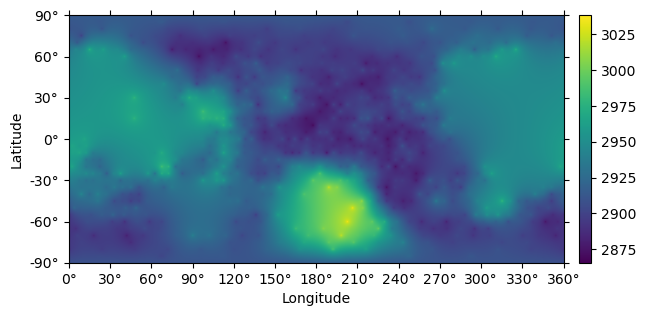

In [4]:
density_grid.plot(colorbar='right')

重力模型GRGM1200B

In [5]:
pot=pysh.datasets.Moon.GRGM1200B()
pot.set_omega(bl.Moon2015.angular_velocity)
pot=pot.change_ref(gm=bl.Moon2015.geocentric_grav_const, r0=bl.Moon2015.radius)
grgm1200 = pot
print(grgm1200)

  name = 'GRGM1200B (Moon)'
  kind = 'real'
  normalization = '4pi'
  csphase = 1
  lmax = 1200
  GM (m3 / s2) = 4902800070000.0
  r0 (m) = 1737151
  omega (rad / s) = 2.6617073e-06
  error_kind = 'unspecified'
  header = ['4.9028001224452998E+12', '1.7380000000000000E+06', '1200', '1200']
  header2 = None
  epoch = None


使用内置的地形数据

In [6]:
topo = pysh.datasets.Moon.LDEM_shape_pa(lmax=1200)
topo.r0 = topo.coeffs[0, 0, 0]

设置参数

In [7]:
thickave = 35.e3
porosity = 0.12
rho_c = 2550.0
rho_m = 3220.0
filter = 1
half = 80

执行反演程序

In [8]:
moho = pyMoho(grgm1200, topo, 1200, rho_c, rho_m, thickave,
                filter_type=filter, half=half, lmax_calc=1200,
                quiet=False, delta_max=50.)

Maximum radius (km) = 1748.121126
Minimum radius (km) = 1728.204994
Maximum Crustal thickness (km) = 6.749761e+01
Minimum Crustal thickness (km) = -1.131708e+01
Delta (km) = 3.880788e+01
Maximum Crustal thickness (km) = 68.846309
Minimum Crustal thickness (km) = 0.041976
Iteration 1
Delta (km) = 1.940394e+01
Maximum Crustal thickness (km) = 67.982549
Minimum Crustal thickness (km) = 1.620047
Iteration 2
Delta (km) = 1.132704e+01
Maximum Crustal thickness (km) = 69.247318
Minimum Crustal thickness (km) = -2.904479
Iteration 3
Delta (km) = 5.663522e+00
Maximum Crustal thickness (km) = 68.420386
Minimum Crustal thickness (km) = 1.170813
Iteration 4
Delta (km) = 1.270196e+00
Maximum Crustal thickness (km) = 69.527764
Minimum Crustal thickness (km) = 1.589664
Iteration 5
Delta (km) = 6.350981e-01
Maximum Crustal thickness (km) = 68.974075
Minimum Crustal thickness (km) = 1.380239
Iteration 6
Delta (km) = 8.715767e-01
Maximum Crustal thickness (km) = 69.724749
Minimum Crustal thickness (km) 

In [9]:
thick_grid = (topo.pad(1200) - moho.pad(1200)).expand(grid='DH2') / 1.e3

(<Figure size 640x428.8 with 2 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

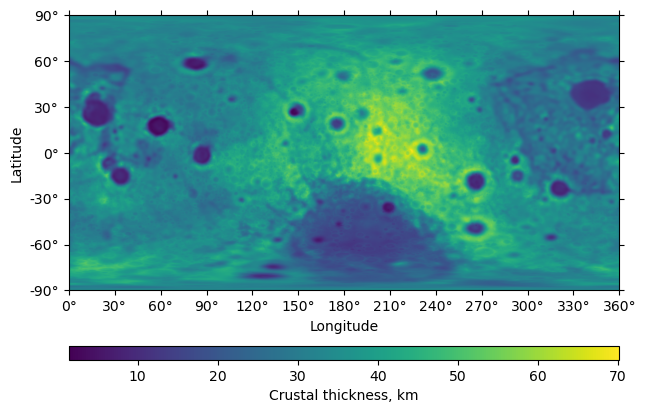

In [10]:
thick_grid.plot(show=True, colorbar='bottom',
                    cb_label='Crustal thickness, km',
                    fname='Thick-Moon-run1.png')

In [13]:
import pickle

pkl_name=result_filename
result={
    "moho": moho,
    "thick_grid": thick_grid,
    "topo": topo,
    "grgm1200": grgm1200,
}
with open(pkl_name, "wb") as f:
    pickle.dump(result, f)